# Encoder-Decoder Architecture for Images

##  Overview

This notebook provides a comprehensive understanding of **Encoder-Decoder architectures** for image processing. We will explore how these networks compress images into meaningful representations and reconstruct them back.

We will cover:
- **Basic Encoder-Decoder** concept and intuition
- **Using Pretrained Encoders** (VGG, ResNet) for feature extraction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 1. Introduction to Encoder-Decoder Architecture

### 1.1 The Core Concept

An **Encoder-Decoder** network is a neural network architecture with two main parts:

| Component | What it Does | Analogy |
|-----------|--------------|---------|
| **Encoder** | Compresses the input into a compact representation | Like summarising a book into key points |
| **Decoder** | Reconstructs output from the compressed representation | Like expanding key points back into a story |

The compressed representation between them is called the **Latent Space** or **Bottleneck**.

### 1.2 Visual Representation

```
  INPUT IMAGE          ENCODER           LATENT SPACE           DECODER          OUTPUT IMAGE
  [64 x 64 x 3]   -->  [Compress]   -->  [1 x 1 x 128]   -->  [Expand]   -->   [64 x 64 x 3]
   (12,288 values)                        (128 values)                          (12,288 values)
```

**Key Insight:** The network must learn to preserve the most important information in a much smaller representation!

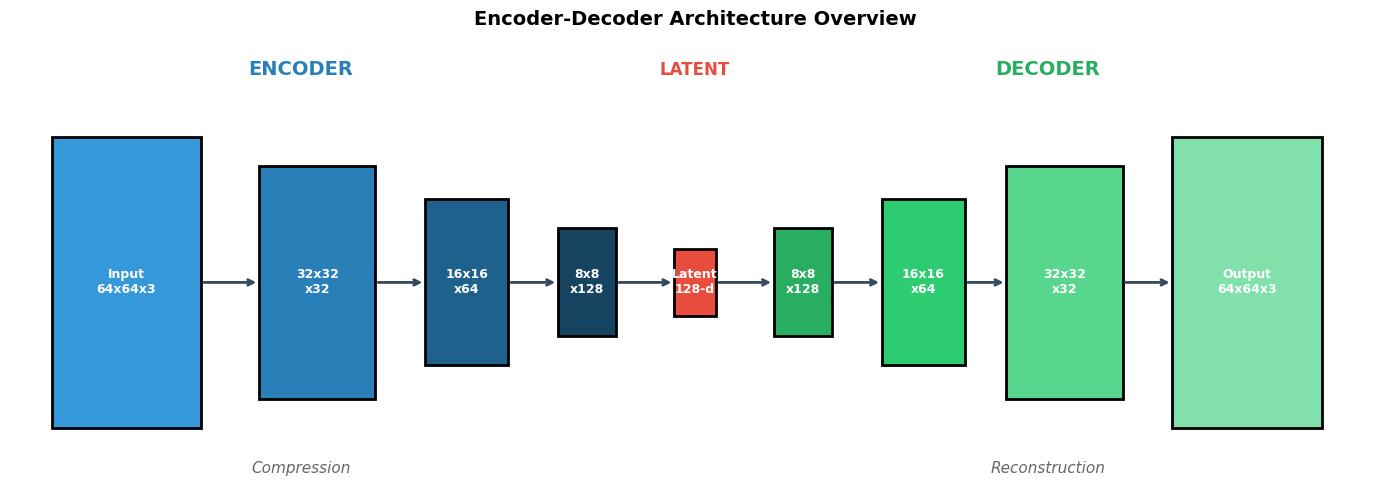

## 2. The Encoder: Compressing Images

### 2.1 What Does the Encoder Do?

The encoder transforms a high-dimensional input (image) into a low-dimensional representation (latent vector).

| Function | Description |
|----------|-------------|
| **Feature Extraction** | Identifies important patterns like edges, textures, shapes |
| **Dimensionality Reduction** | Compresses spatial information into fewer dimensions |

### 2.2 The Encoding Process

As the image passes through the encoder:

1. **Early layers** detect low-level features (edges, colors)
2. **Middle layers** detect mid-level features (textures, patterns)
3. **Deep layers** detect high-level features (objects, concepts)
4. **Final layer** produces the compressed latent representation

### 2.3 Building a Simple Encoder

In [2]:
def build_encoder(input_shape=(64, 64, 3), latent_dim=128):
    """
    Build a simple convolutional encoder.

    Args:
        input_shape: Shape of input images (H, W, C)
        latent_dim: Dimension of the latent space

    Returns:
        encoder: Keras Model
    """
    inputs = layers.Input(shape=input_shape)

    # Block 1: 64x64 -> 32x32
    x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block 2: 32x32 -> 16x16
    x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block 3: 16x16 -> 8x8
    x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Flatten and create latent vector
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name='latent_vector')(x)

    encoder = Model(inputs, latent, name='encoder')
    return encoder

# Build and display encoder
encoder = build_encoder(input_shape=(64, 64, 3), latent_dim=128)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │     1,048,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,848 (4.36 MB)

 Trainable params: 1,142,400 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 2.4 Using Pretrained Models as Encoders

Instead of training an encoder from scratch, we can use **pretrained models** like VGG16 or ResNet. These models have already learned powerful feature representations from millions of images.

**Benefits of Pretrained Encoders:**
- Already learned rich visual features
- Faster training (transfer learning)
- Better performance on smaller datasets
- Proven architectures

In [3]:
def build_pretrained_encoder(input_shape=(64, 64, 3), latent_dim=128, backbone='vgg16'):
    """
    Build an encoder using a pretrained backbone.

    Args:
        input_shape: Shape of input images
        latent_dim: Dimension of the latent space
        backbone: 'vgg16' or 'resnet50'
    """
    inputs = layers.Input(shape=input_shape)

    # Load pretrained backbone (without top classification layers)
    if backbone == 'vgg16':
        base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)
    elif backbone == 'resnet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze pretrained weights (optional - for transfer learning)
    base_model.trainable = False

    # Add our own layers on top
    x = layers.GlobalAveragePooling2D()(base_model.output)
    latent = layers.Dense(latent_dim, name='latent_vector')(x)

    encoder = Model(inputs, latent, name=f'{backbone}_encoder')
    return encoder

# Build VGG16-based encoder
print("Building VGG16-based Encoder...")
vgg_encoder = build_pretrained_encoder(input_shape=(64, 64, 3), latent_dim=128, backbone='vgg16')

print(f"\nInput shape:  {vgg_encoder.input_shape}")
print(f"Output shape: {vgg_encoder.output_shape}")
print(f"Total parameters: {vgg_encoder.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in vgg_encoder.trainable_weights]):,}")

Building VGG16-based Encoder...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Input shape:  (None, 64, 64, 3)
Output shape: (None, 128)
Total parameters: 14,780,352
Trainable parameters: 65,664


## 3. The Decoder: Reconstructing Images

### 3.1 What Does the Decoder Do?

The decoder is the **reverse** of the encoder. It takes the compressed latent representation and reconstructs the original image (or a target output).

| Function | Description |
|----------|-------------|
| **Upsampling** | Increases spatial dimensions back to original size |
| **Feature Reconstruction** | Translates abstract features back into pixel values |

### 3.2 Upsampling Techniques

The decoder needs to increase spatial dimensions. Common methods:

| Method | Description | When to Use |
|--------|-------------|-------------|
| **Transposed Convolution** | Learnable upsampling with trainable filters | When you want the network to learn how to upsample |
| **Bilinear Upsampling + Conv** | Resize then convolve | Avoids checkerboard artifacts |
| **PixelShuffle** | Rearranges channels into spatial dimensions | Efficient for super-resolution |

### 3.3 Building a Simple Decoder

In [4]:
def build_decoder(latent_dim=128, output_shape=(64, 64, 3)):
    """
    Build a simple convolutional decoder.

    Args:
        latent_dim: Dimension of the latent space
        output_shape: Shape of output images (H, W, C)

    Returns:
        decoder: Keras Model
    """
    latent_inputs = layers.Input(shape=(latent_dim,))

    # Project latent vector to spatial format
    # We start from 8x8 spatial size with 128 channels
    x = layers.Dense(8 * 8 * 128)(latent_inputs)
    x = layers.Reshape((8, 8, 128))(x)

    # Block 1: 8x8 -> 16x16
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block 2: 16x16 -> 32x32
    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block 3: 32x32 -> 64x64
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Output layer: produce RGB image with sigmoid activation (0-1 range)
    outputs = layers.Conv2D(output_shape[2], kernel_size=3, padding='same', activation='sigmoid')(x)

    decoder = Model(latent_inputs, outputs, name='decoder')
    return decoder

# Build and display decoder
decoder = build_decoder(latent_dim=128, output_shape=(64, 64, 3))
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298,371 (4.95 MB)

 Trainable params: 1,297,923 (4.95 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Practical Implementation

### 5.1 Preparing Data

We will use the MNIST dataset for demonstration:

Training data shape: (60000, 64, 64, 1)
Test data shape: (10000, 64, 64, 1)


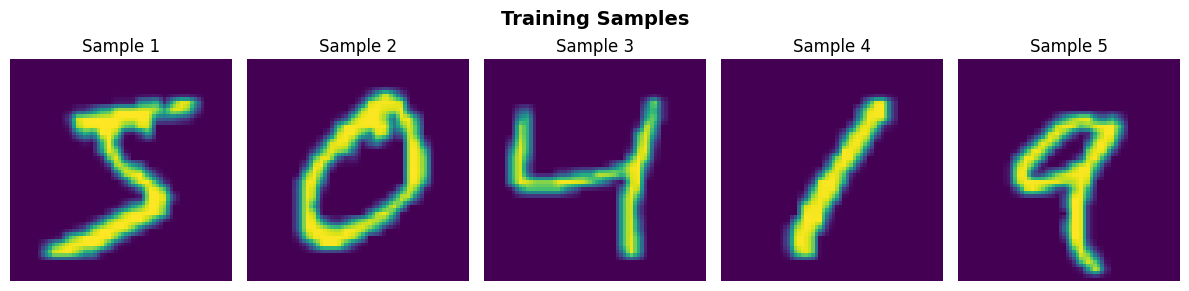

In [39]:
# Load and preprocess MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and resize to 64x64
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Resize using tf.image.resize
x_train = tf.image.resize(x_train[..., tf.newaxis], (64, 64)).numpy()
x_test = tf.image.resize(x_test[..., tf.newaxis], (64, 64)).numpy()

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i])
    ax.axis('off')
    ax.set_title(f'Sample {i+1}')
plt.suptitle('Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Simple Encoder-Decoder

In [42]:
# Simple Convolutional Encoder–Decoder (Autoencoder)

input_img = keras.Input(shape=(64, 64, 1))  # let's use a grayscale input here

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_25 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_26 (UpSampling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,075 (293.26 KB)

 Trainable params: 75,075 (293.26 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Visualising Results

#### Reconstruction Quality

The encoder–decoder is trained to learn a **structure-preserving compression** of the input image. To evaluate what the model has learned, numerical loss values are not sufficient.

Instead, we visually compare:
- the original input image
- the reconstructed output image

Good reconstructions indicate that:
- spatial structure is preserved
- important visual patterns survive the bottleneck
- the decoder has learned a meaningful inverse mapping

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


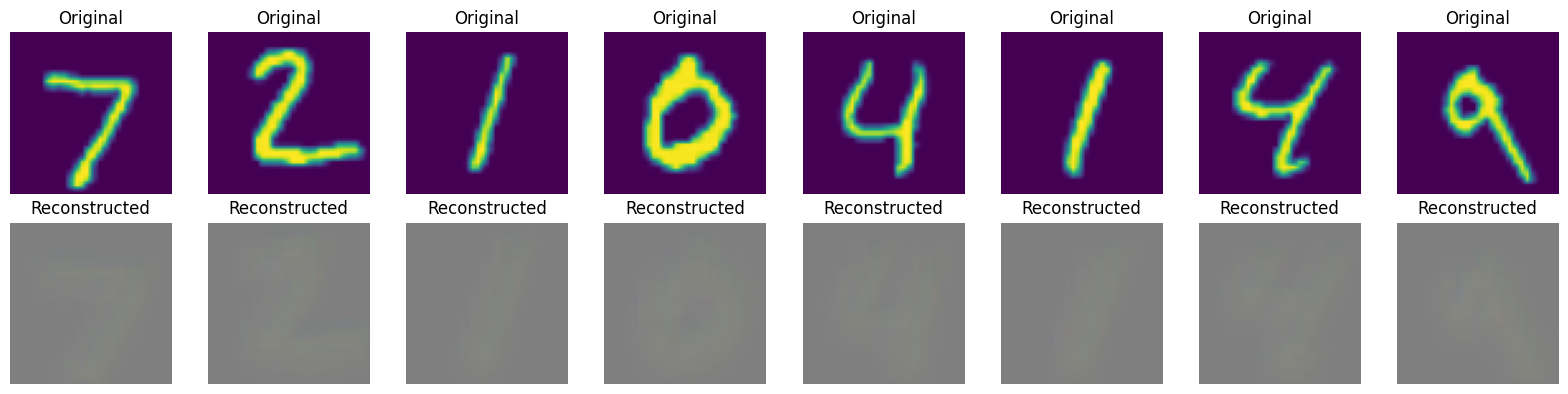

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct test images using the trained encoder–decoder
reconstructed = autoencoder.predict(x_test)

n = 8  # number of examples to display
plt.figure(figsize=(16, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze())
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='grey', vmin=0, vmax=1)
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

The reconstructed digits with a pure encoder-decoder are very blurry and faint.

Even with increased depth or capacity, a plain encoder-decoder tends to produce smooth, blurred reconstructions because spatial detail is progressively lost during downsampling and cannot be perfectly recovered during decoding.

The decoder learns an approximate inverse, not a true reconstruction of lost information. Increasing depth or filters improves representation capacity but does not restore localisation. As a result, boundaries and thin structures appear blurred or washed out.

### Exploring the Latent Space

The encoder does not produce a label or a final prediction. Instead, it maps each input image to a compact latent representation.

This latent space captures shape, stroke structure, and high-level visual patterns

Even though the model is not trained for classification, images with similar structure often map to nearby regions in latent space

We visualise this by:
1. Extracting encoder outputs
2. Reducing dimensionality for visualisation
3. Colouring points by true digit labels (for interpretation only)

A common method we use for reducing dimensionality is PCA

We can also interpolate between two images in latent space to see smooth transitions:

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


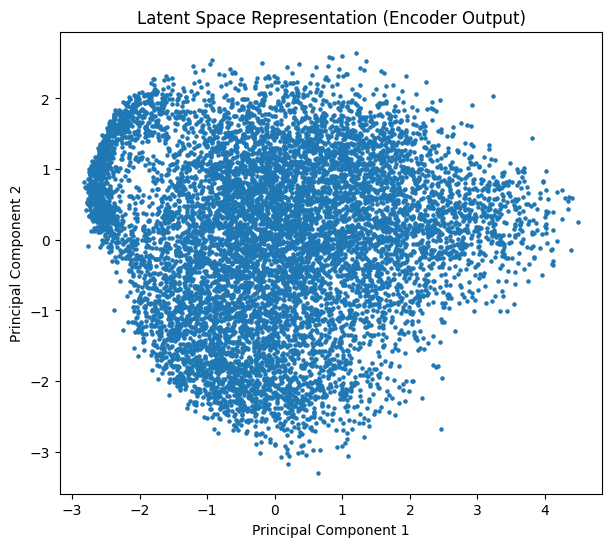

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Create a model that outputs the encoder representation
encoder_model = keras.Model(inputs=autoencoder.input, outputs=encoded)

# Obtain latent representations
latent = encoder_model.predict(x_test)

# Flatten spatial dimensions
latent_flat = latent.reshape(latent.shape[0], -1)

# Reduce to 2D for visualisation
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_flat)

# Plot latent space
plt.figure(figsize=(7, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], s=5)
plt.title("Latent Space Representation (Encoder Output)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Applications

| Application | Description |
|-------------|-------------|
| **Image Reconstruction** | Denoising, inpainting, compression |
| **Image Generation** | Creating new images from random samples |
| **Feature Learning** | Unsupervised representation learning |
| **Anomaly Detection** | Detecting unusual patterns via reconstruction error |
| **Data Augmentation** | Generating synthetic training data |


### Key Observation

This model **is already an encoder–decoder**:
- Encoder → hierarchical abstraction + spatial compression
- Decoder → learned upsampling + spatial reconstruction

This architecture generalises directly to:
- U‑Net (skip connections)
- Seq2Seq models
- Image‑to‑image translation systems
